# Connected 3D Blobs Realizations (`phi = 0.20`) with Pore-Network Statistics and `Kx`

Objective:
- generate 30 connected **3D blobs** porous-media realizations at target porosity `phi=0.20`
- extract one pore network per realization
- characterize:
  - pore size distribution (PSD)
  - throat size distribution
  - coordination number distribution
- estimate absolute permeability in the x-direction (`Kx`) for each realization
- plot the `Kx` distribution over all realizations

Scientific notes:
- `phi=0.20` in 3D can still produce occasional non-spanning samples, so we use a retry loop
  and keep only successful x-spanning realizations.
- This is a synthetic morphology benchmark; quantitative transfer to a specific rock requires
  calibration/validation against image-based or laboratory data.


In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm as _tqdm
except Exception:  # pragma: no cover
    _tqdm = None

from voids.generators import (
    generate_spanning_blobs_matrix,
    generate_spanning_multiscale_blobs_matrix,
)
from voids.image import extract_spanning_pore_network
from voids.geom import characteristic_size
from voids.graph.metrics import coordination_numbers
from voids.physics.petrophysics import absolute_porosity, effective_porosity
from voids.physics.singlephase import (
    FluidSinglePhase,
    PressureBC,
    SinglePhaseOptions,
    solve,
)

/Users/dtvolpatto/Work/voids/.pixi/envs/lbm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def iter_progress(iterable, *, desc: str, enabled: bool = True):
    if enabled and _tqdm is not None:
        return _tqdm(iterable, desc=desc, dynamic_ncols=True, leave=False)
    return iterable

In [3]:
# Study controls (3D synthetic)
N_REALIZATIONS = 30
TARGET_POROSITY = 0.20

SHAPE_3D = (256, 256, 256)  # (nx, ny, nz)
FLOW_AXIS = "x"
FLOW_AXIS_INDEX = 0
VOXEL_SIZE_M = 10.0e-6

# Generator selector
GENERATOR_NAME = "blobs"  # "blobs" or "multiscale_blobs"

# Single-scale blobs control
BLOBINESS = 2.2

# Multiscale blobs controls
MULTISCALE_BLOBINESS_PRIMARY = (0.8, 0.8, 1.5)
MULTISCALE_BLOBINESS_SECONDARY = (3.5, 3.5, 7.0)
MULTISCALE_PRIMARY_WEIGHT = 0.70

BASE_SEED = 20261408
ATTEMPT_BUDGET_MULTIPLIER = 8

USE_TQDM = True
N_PREVIEW_VOLUMES = 3

fluid = FluidSinglePhase(viscosity=1.0e-3)
bc = PressureBC("inlet_xmin", "outlet_xmax", pin=2.0e5, pout=1.0e5)
solve_options = SinglePhaseOptions(conductance_model="valvatne_blunt", solver="direct")

print("N realizations:", N_REALIZATIONS)
print("Target porosity:", TARGET_POROSITY)
print("Shape:", SHAPE_3D)
print("Flow axis:", FLOW_AXIS)
print("Generator:", GENERATOR_NAME)
print("Base seed:", BASE_SEED)
if GENERATOR_NAME == "blobs":
    print("Blobiness:", BLOBINESS)
elif GENERATOR_NAME == "multiscale_blobs":
    print("Primary blobiness:", MULTISCALE_BLOBINESS_PRIMARY)
    print("Secondary blobiness:", MULTISCALE_BLOBINESS_SECONDARY)
    print("Primary weight:", MULTISCALE_PRIMARY_WEIGHT)
else:
    raise ValueError(f"Unsupported GENERATOR_NAME: {GENERATOR_NAME}")
max_total_attempts = max(
    int(N_REALIZATIONS * ATTEMPT_BUDGET_MULTIPLIER), int(N_REALIZATIONS)
)
print("Attempt budget:", max_total_attempts)
print(
    "Image reproducibility rule: for this exact configuration, the notebook scans "
    "the same seed stream starting at BASE_SEED and keeps the first successful realizations."
)

N realizations: 30
Target porosity: 0.2
Shape: (256, 256, 256)
Flow axis: x
Generator: blobs
Base seed: 20261408
Blobiness: 2.2
Attempt budget: 240
Image reproducibility rule: for this exact configuration, the notebook scans the same seed stream starting at BASE_SEED and keeps the first successful realizations.


In [4]:
rows: list[dict[str, float | int | str]] = []
payloads: list[dict[str, object]] = []
preview_volumes: list[tuple[int, np.ndarray]] = []
failures: list[dict[str, object]] = []
accepted_seed_starts: list[int] = []
seed_schedule = [BASE_SEED + attempt for attempt in range(max_total_attempts)]
iterator = enumerate(
    iter_progress(seed_schedule, desc="Generating 3D realizations", enabled=USE_TQDM),
    start=1,
)

for loop_id, seed_start in iterator:
    if len(rows) >= N_REALIZATIONS:
        break

    realization_id = len(rows) + 1

    try:
        if GENERATOR_NAME == "blobs":
            binary_void, seed_used = generate_spanning_blobs_matrix(
                shape=SHAPE_3D,
                porosity=TARGET_POROSITY,
                blobiness=BLOBINESS,
                axis_index=FLOW_AXIS_INDEX,
                seed_start=seed_start,
                max_tries=1,
            )
        elif GENERATOR_NAME == "multiscale_blobs":
            binary_void, seed_used = generate_spanning_multiscale_blobs_matrix(
                shape=SHAPE_3D,
                porosity=TARGET_POROSITY,
                blobiness_primary=MULTISCALE_BLOBINESS_PRIMARY,
                blobiness_secondary=MULTISCALE_BLOBINESS_SECONDARY,
                primary_weight=MULTISCALE_PRIMARY_WEIGHT,
                axis_index=FLOW_AXIS_INDEX,
                seed_start=seed_start,
                max_tries=1,
            )
        else:  # pragma: no cover - guarded above
            raise ValueError(f"Unsupported GENERATOR_NAME: {GENERATOR_NAME}")

        extract = extract_spanning_pore_network(
            binary_void.astype(int),
            voxel_size=VOXEL_SIZE_M,
            flow_axis=FLOW_AXIS,
            length_unit="m",
            provenance_notes={
                "study": "connected_porous_media_3d_blobs_phi020",
                "realization": realization_id,
                "generator_name": GENERATOR_NAME,
                "seed_start": int(seed_start),
                "seed_used": int(seed_used),
                "target_porosity": TARGET_POROSITY,
                "blobiness": BLOBINESS if GENERATOR_NAME == "blobs" else None,
                "blobiness_primary": (
                    list(MULTISCALE_BLOBINESS_PRIMARY)
                    if GENERATOR_NAME == "multiscale_blobs"
                    else None
                ),
                "blobiness_secondary": (
                    list(MULTISCALE_BLOBINESS_SECONDARY)
                    if GENERATOR_NAME == "multiscale_blobs"
                    else None
                ),
                "primary_weight": (
                    MULTISCALE_PRIMARY_WEIGHT
                    if GENERATOR_NAME == "multiscale_blobs"
                    else None
                ),
            },
        )
        net = extract.net

        res = solve(net, fluid=fluid, bc=bc, axis=FLOW_AXIS, options=solve_options)
        kx = float(res.permeability[FLOW_AXIS])

        pore_size_m, pore_field = characteristic_size(
            net.pore, expected_shape=(net.Np,)
        )
        throat_size_m, throat_field = characteristic_size(
            net.throat, expected_shape=(net.Nt,)
        )
        pore_size_um = 1.0e6 * pore_size_m
        throat_size_um = 1.0e6 * throat_size_m
        coordination = coordination_numbers(net).astype(int)

        phi_image = float(binary_void.mean())
        phi_abs = float(absolute_porosity(net))
        phi_eff_x = float(effective_porosity(net, axis=FLOW_AXIS))

        rows.append(
            {
                "realization": realization_id,
                "seed_start": int(seed_start),
                "seed_used": int(seed_used),
                "phi_image": phi_image,
                "phi_abs_network": phi_abs,
                "phi_eff_x_network": phi_eff_x,
                "Np": int(net.Np),
                "Nt": int(net.Nt),
                "pore_size_field": pore_field,
                "throat_size_field": throat_field,
                "pore_size_mean_um": float(np.mean(pore_size_um)),
                "pore_size_p50_um": float(np.median(pore_size_um)),
                "throat_size_mean_um": float(np.mean(throat_size_um)),
                "throat_size_p50_um": float(np.median(throat_size_um)),
                "coordination_mean": float(np.mean(coordination)),
                "kabs_x_m2": kx,
                "mass_balance_error": float(res.mass_balance_error),
            }
        )
        payloads.append(
            {
                "realization": realization_id,
                "binary_void": binary_void,
                "pore_size_um": pore_size_um,
                "throat_size_um": throat_size_um,
                "coordination": coordination,
            }
        )

        if len(preview_volumes) < N_PREVIEW_VOLUMES:
            preview_volumes.append((realization_id, binary_void))
        accepted_seed_starts.append(int(seed_start))
    except Exception as exc:
        failures.append(
            {"attempt": loop_id, "seed_start": seed_start, "error": str(exc)}
        )
        continue

if len(rows) < N_REALIZATIONS:
    raise RuntimeError(
        f"Collected {len(rows)} successful realizations out of {N_REALIZATIONS} requested "
        f"after {len(seed_schedule)} attempts. For the same configuration, increasing "
        "ATTEMPT_BUDGET_MULTIPLIER preserves reproducibility because the seed stream stays fixed."
    )

summary_df = pd.DataFrame(rows).sort_values("realization").reset_index(drop=True)
summary_df

Generating 3D realizations:  12%|█▎        | 30/240 [08:19<57:37, 16.46s/it]  

,realization,seed_start,seed_used,phi_image,phi_abs_network,phi_eff_x_network,Np,Nt,pore_size_field,throat_size_field,pore_size_mean_um,pore_size_p50_um,throat_size_mean_um,throat_size_p50_um,coordination_mean,kabs_x_m2,mass_balance_error
0,1,20261408,20261408,0.2,0.195313,0.195313,6059,8499,diameter_equivalent,diameter_equivalent,88.943094,87.101538,48.724910,45.135167,2.805413,5.615085e-13,2.387215e-20
1,2,20261409,20261409,0.2,0.194520,0.194520,6073,8482,diameter_equivalent,diameter_equivalent,89.215098,88.342468,48.573297,45.135167,2.793348,4.956172e-13,2.693080e-20
2,3,20261410,20261410,0.2,0.195355,0.195355,6074,8478,diameter_equivalent,diameter_equivalent,89.481068,88.219921,48.939690,46.524265,2.791571,4.493384e-13,2.664687e-20
3,4,20261411,20261411,0.2,0.197165,0.197165,6127,8509,diameter_equivalent,diameter_equivalent,89.081951,87.932710,48.477966,45.135167,2.777542,4.689400e-13,2.557514e-20
4,5,20261412,20261412,0.2,0.197492,0.197492,6102,8464,diameter_equivalent,diameter_equivalent,89.682835,88.423965,49.490400,46.524265,2.774172,4.979881e-13,2.624127e-20
5,6,20261413,20261413,0.2,0.194439,0.194439,5940,8354,diameter_equivalent,diameter_equivalent,90.199673,88.667558,49.099162,46.524265,2.812795,4.878999e-13,2.618665e-20
6,7,20261414,20261414,0.2,0.196956,0.196956,6102,8496,diameter_equivalent,diameter_equivalent,89.339699,88.383216,49.032703,46.524265,2.784661,4.659992e-13,2.271554e-20
7,8,20261415,20261415,0.2,0.195857,0.195857,6140,8448,diameter_equivalent,diameter_equivalent,88.809996,87.101538,49.285450,46.524265,2.751792,4.936610e-13,2.711476e-20
8,9,20261416,20261416,0.2,0.196811,0.196811,6264,8576,diameter_equivalent,diameter_equivalent,88.464151,86.933388,48.630173,45.135167,2.738186,4.144458e-13,2.714861e-20
9,10,20261417,20261417,0.2,0.194914,0.194914,6034,8399,diameter_equivalent,diameter_equivalent,89.216517,88.179022,48.893758,45.135167,2.783891,4.446778e-13,2.579288e-20


In [5]:
print("Successful realizations:", len(summary_df))
print("Accepted seed starts:")
print(accepted_seed_starts)
print("Failed attempts:", len(failures))
print("First 5 failures (if any):")
for item in failures[:5]:
    print(item)

summary_stats = summary_df[
    [
        "phi_image",
        "phi_abs_network",
        "phi_eff_x_network",
        "Np",
        "Nt",
        "pore_size_mean_um",
        "throat_size_mean_um",
        "coordination_mean",
        "kabs_x_m2",
        "mass_balance_error",
    ]
].describe(percentiles=[0.1, 0.5, 0.9])
summary_stats

Successful realizations: 30
Accepted seed starts:
[20261408, 20261409, 20261410, 20261411, 20261412, 20261413, 20261414, 20261415, 20261416, 20261417, 20261418, 20261419, 20261420, 20261421, 20261422, 20261423, 20261424, 20261425, 20261426, 20261427, 20261428, 20261429, 20261430, 20261431, 20261432, 20261433, 20261434, 20261435, 20261436, 20261437]
Failed attempts: 0
First 5 failures (if any):


,phi_image,phi_abs_network,phi_eff_x_network,Np,Nt,pore_size_mean_um,throat_size_mean_um,coordination_mean,kabs_x_m2,mass_balance_error
count,30.0,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,3.000000e+01,3.000000e+01
mean,0.2,0.196431,0.196431,6103.866667,8488.566667,89.197567,48.875454,2.781524,4.767235e-13,2.569420e-20
std,0.0,0.000984,0.000984,91.512476,112.168188,0.426149,0.280038,0.021870,4.798072e-14,1.818697e-21
min,0.2,0.194439,0.194439,5860.000000,8185.000000,88.464151,48.407747,2.738186,3.921822e-13,2.120330e-20
10%,0.2,0.195217,0.195217,6017.800000,8354.900000,88.767134,48.572419,2.751413,4.139971e-13,2.298944e-20
50%,0.2,0.196607,0.196607,6102.000000,8486.000000,89.148524,48.823178,2.781014,4.687418e-13,2.595411e-20
90%,0.2,0.197571,0.197571,6209.400000,8603.300000,89.694907,49.259176,2.810391,5.329310e-13,2.747865e-20
max,0.2,0.198825,0.198825,6321.000000,8732.000000,90.299861,49.490400,2.824033,6.166573e-13,2.970513e-20


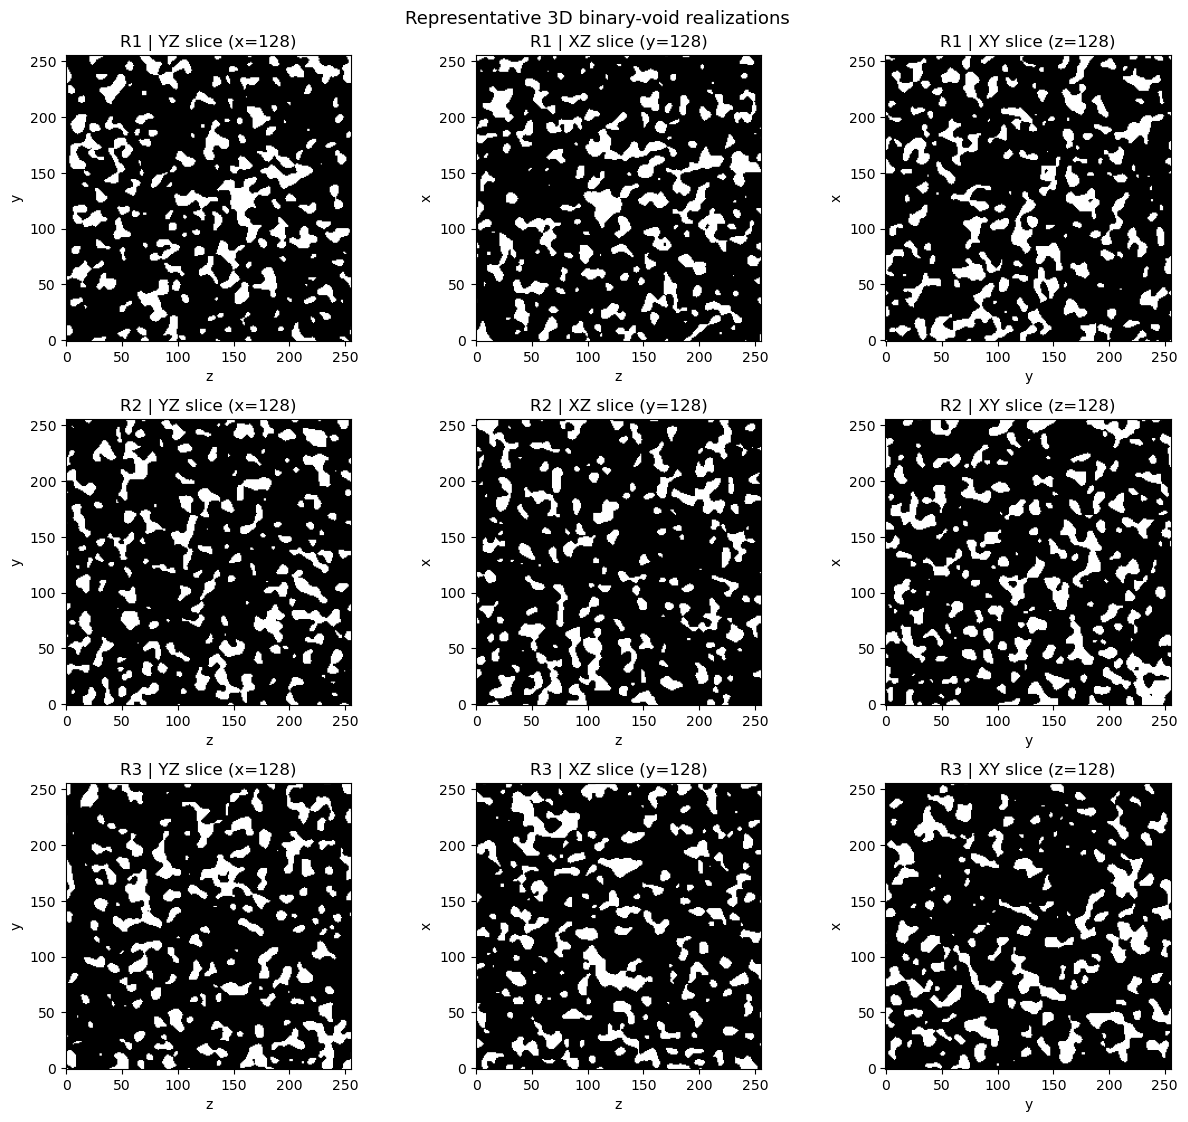

In [6]:
# Visualize a few representative realizations with orthogonal middle slices.
fig, axes = plt.subplots(
    len(preview_volumes), 3, figsize=(12.5, 3.8 * len(preview_volumes))
)
axes = np.atleast_2d(axes)

for row, (rid, vol) in enumerate(preview_volumes):
    mx, my, mz = vol.shape[0] // 2, vol.shape[1] // 2, vol.shape[2] // 2

    axes[row, 0].imshow(vol[mx, :, :], cmap="gray", origin="lower")
    axes[row, 0].set_title(f"R{rid} | YZ slice (x={mx})")
    axes[row, 0].set_xlabel("z")
    axes[row, 0].set_ylabel("y")

    axes[row, 1].imshow(vol[:, my, :], cmap="gray", origin="lower")
    axes[row, 1].set_title(f"R{rid} | XZ slice (y={my})")
    axes[row, 1].set_xlabel("z")
    axes[row, 1].set_ylabel("x")

    axes[row, 2].imshow(vol[:, :, mz], cmap="gray", origin="lower")
    axes[row, 2].set_title(f"R{rid} | XY slice (z={mz})")
    axes[row, 2].set_xlabel("y")
    axes[row, 2].set_ylabel("x")

fig.suptitle("Representative 3D binary-void realizations", fontsize=13)
plt.tight_layout()
plt.show()

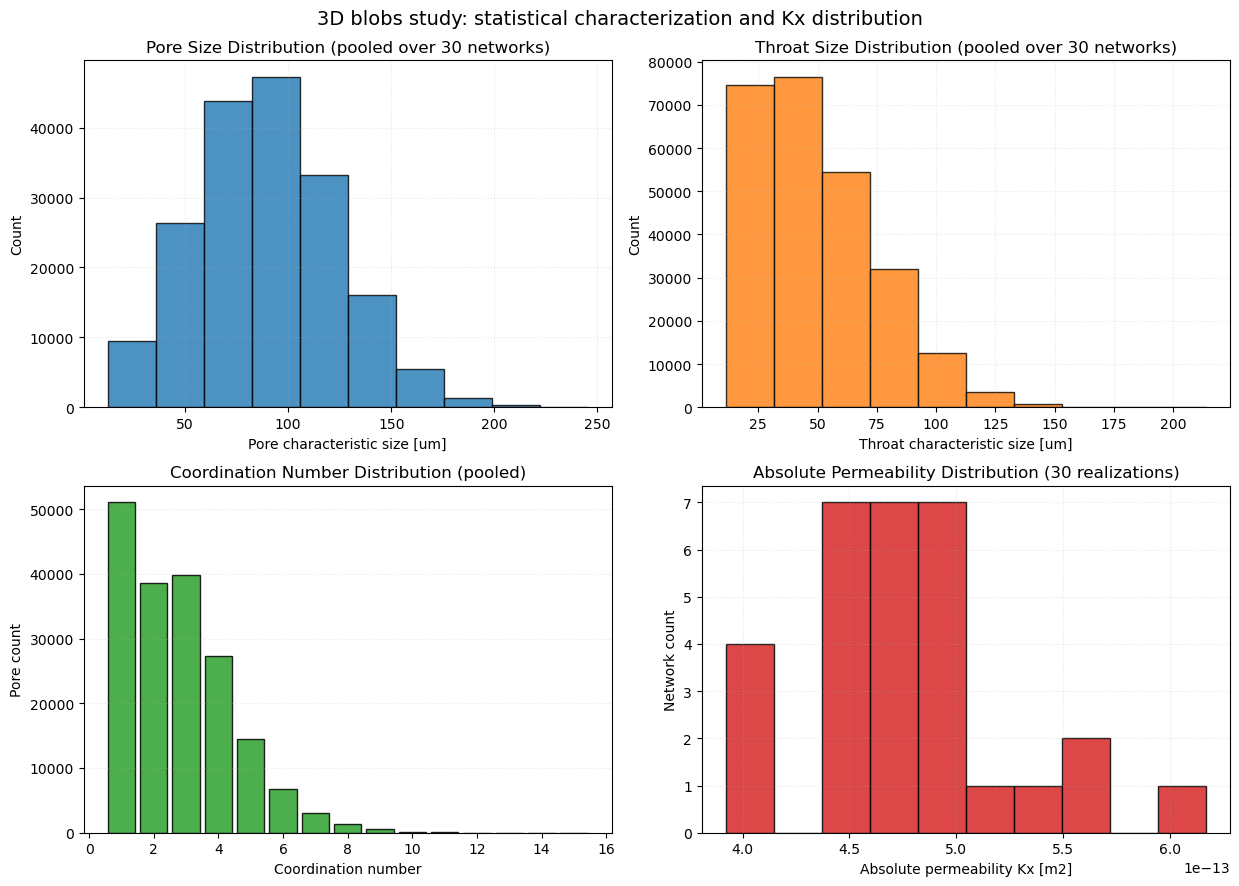

In [7]:
# Aggregate distributions over all extracted networks.
all_pore_sizes_um = np.concatenate([p["pore_size_um"] for p in payloads])
all_throat_sizes_um = np.concatenate([p["throat_size_um"] for p in payloads])
all_coordination = np.concatenate([p["coordination"] for p in payloads]).astype(int)
all_kx = summary_df["kabs_x_m2"].to_numpy(dtype=float)

coord_vals, coord_counts = np.unique(all_coordination, return_counts=True)

fig, axes = plt.subplots(2, 2, figsize=(12.5, 9.0))

axes[0, 0].hist(all_pore_sizes_um, color="tab:blue", edgecolor="black", alpha=0.8)
axes[0, 0].set_xlabel("Pore characteristic size [um]")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Pore Size Distribution (pooled over 30 networks)")
axes[0, 0].grid(alpha=0.3, linestyle=":")

axes[0, 1].hist(
    all_throat_sizes_um,
    color="tab:orange",
    edgecolor="black",
    alpha=0.8,
)
axes[0, 1].set_xlabel("Throat characteristic size [um]")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Throat Size Distribution (pooled over 30 networks)")
axes[0, 1].grid(alpha=0.3, linestyle=":")

axes[1, 0].bar(
    coord_vals,
    coord_counts,
    width=0.85,
    color="tab:green",
    edgecolor="black",
    alpha=0.85,
)
axes[1, 0].set_xlabel("Coordination number")
axes[1, 0].set_ylabel("Pore count")
axes[1, 0].set_title("Coordination Number Distribution (pooled)")
axes[1, 0].grid(alpha=0.3, linestyle=":", axis="y")

axes[1, 1].hist(all_kx, color="tab:red", edgecolor="black", alpha=0.85)
axes[1, 1].set_xlabel("Absolute permeability Kx [m2]")
axes[1, 1].set_ylabel("Network count")
axes[1, 1].set_title("Absolute Permeability Distribution (30 realizations)")
axes[1, 1].grid(alpha=0.3, linestyle=":")

fig.suptitle(
    "3D blobs study: statistical characterization and Kx distribution", fontsize=14
)
plt.tight_layout()
plt.show()

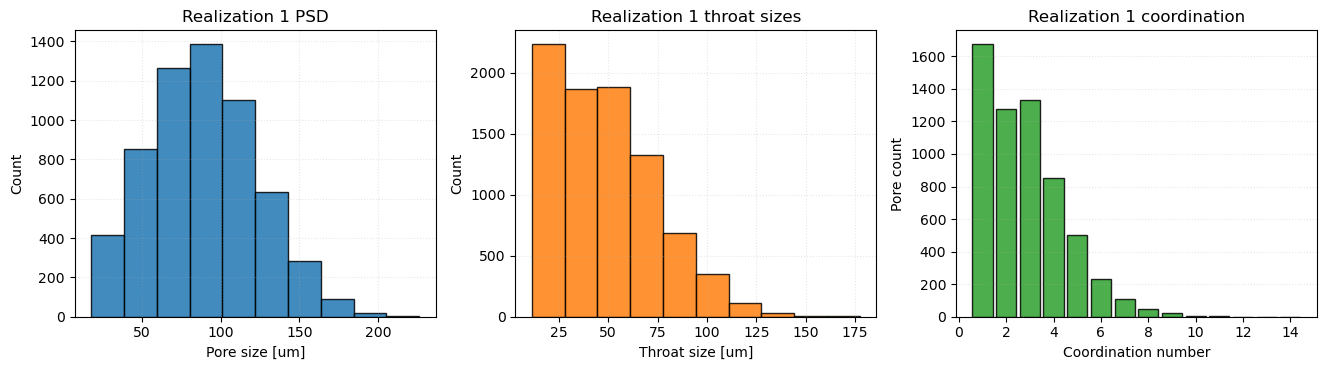

In [8]:
# Optional: inspect one specific realization in detail.
def plot_single_realization_distributions(realization: int) -> None:
    item = next(p for p in payloads if int(p["realization"]) == int(realization))
    pore_size_um = np.asarray(item["pore_size_um"], dtype=float)
    throat_size_um = np.asarray(item["throat_size_um"], dtype=float)
    coordination = np.asarray(item["coordination"], dtype=int)
    coord_vals_local, coord_counts_local = np.unique(coordination, return_counts=True)

    fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
    axes[0].hist(pore_size_um, color="tab:blue", edgecolor="black", alpha=0.85)
    axes[0].set_title(f"Realization {realization} PSD")
    axes[0].set_xlabel("Pore size [um]")
    axes[0].set_ylabel("Count")
    axes[0].grid(alpha=0.3, linestyle=":")

    axes[1].hist(throat_size_um, color="tab:orange", edgecolor="black", alpha=0.85)
    axes[1].set_title(f"Realization {realization} throat sizes")
    axes[1].set_xlabel("Throat size [um]")
    axes[1].set_ylabel("Count")
    axes[1].grid(alpha=0.3, linestyle=":")

    axes[2].bar(
        coord_vals_local,
        coord_counts_local,
        width=0.85,
        color="tab:green",
        edgecolor="black",
        alpha=0.85,
    )
    axes[2].set_title(f"Realization {realization} coordination")
    axes[2].set_xlabel("Coordination number")
    axes[2].set_ylabel("Pore count")
    axes[2].grid(alpha=0.3, linestyle=":", axis="y")

    plt.tight_layout()
    plt.show()


plot_single_realization_distributions(realization=1)

## Assumptions and possible weak points

1. We assume `blobs` with `blobiness=2.2` at this voxel resolution provides a meaningful synthetic 3D ensemble.
   This can be incorrect if your target material has very different texture/connectivity scales.
2. Conditioning on x-spanning realizations is useful for transport studies, but it can bias morphology statistics
   relative to the unconditional `phi=0.20` blobs ensemble.
3. `Kx` is estimated on extracted pore networks (`snow2` + conduit model), not from full voxel-scale DNS.
   Extraction/model uncertainty can shift absolute values and distribution width.
4. If you need lower Monte Carlo uncertainty on the tails of `Kx`, increase realization count beyond 30 and
   monitor convergence of quantiles (e.g., p10, p50, p90).